# Predicción de Ventas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)

print(df.head())
print(df.columns)

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633
Index(['date', 'sales'], dtype='str')


In [3]:
# Convertimos la columna de fechas a tipo datetime (fecha real, no texto)

df['date'] = pd.to_datetime(df['date'])

In [4]:
# Establecemos la fecha como índice del DataFrame, sino pandas colapsa 

df = df.set_index('date')

In [5]:
# Guardamos solo la columna de ventas como una Series (lista con índice de fechas)

serie = df['sales']

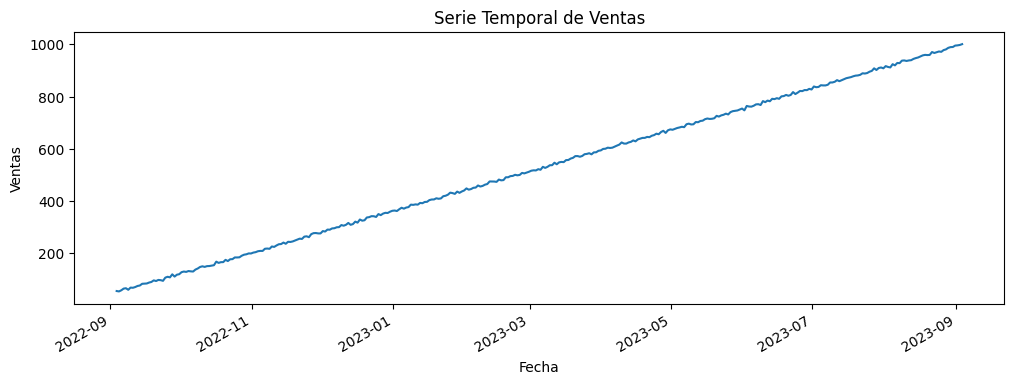

In [6]:
# Graficamos la serie temporal para verla visualmente
serie.plot(title='Serie Temporal de Ventas', figsize=(12, 4))
plt.ylabel('Ventas')
plt.xlabel('Fecha')
plt.show()

In [7]:
#¿Cuál es el tensor de la serie temporal?

tensor = serie.index.to_series().diff().min()
print("Tensor (unidad mínima de tiempo):", tensor)

Tensor (unidad mínima de tiempo): 1 days 00:00:00


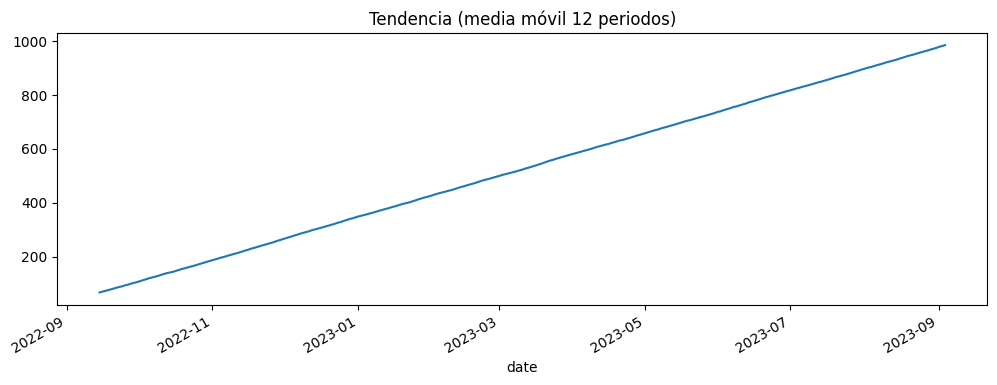

In [8]:
#¿Cuál es la tendencia?
#rolling(window=12).mean() suaviza los datos con ventana de 12 periodos

media_movil = serie.rolling(window=12).mean()
media_movil.plot(title='Tendencia (media móvil 12 periodos)', figsize=(12, 4))
plt.show()



Observamos que es una tendencia creciete

In [10]:
#¿Es estacionaria?
# uso el test de Dickey-Fuller

resultado_adf = adfuller(serie.dropna())

print("Estadístico ADF:", resultado_adf[0])
print("P-valor:", resultado_adf[1])

Estadístico ADF: 0.545414193706378
P-valor: 0.9861899815311064


con el p valor nos indica si es estacionaria en este caso p-valor >=0.05 entonces decimos que NO es estacionaria

In [11]:
#¿Existe variabilidad o presencia de ruido?
# La desviación estándar alta indica mucha variabilidad o ruido en los datos

print("Desviación estándar (variabilidad):", serie.std())
print("Media de la serie:", serie.mean())

Desviación estándar (variabilidad): 275.08969801796553
Media de la serie: 524.963967941629


In [12]:
# El coeficiente de variación (CV) normaliza la variabilidad respecto a la media

cv = (serie.std() / serie.mean()) * 100
print("Coeficiente de variación (%):", round(cv, 2))

Coeficiente de variación (%): 52.4


el CV es mayor al 30% por lo que podemos decir que hay mucha varibilidad o ruido

# Entrenar Arima

In [13]:
n = len(serie)
corte = int(n * 0.8)

train = serie[:corte]

test = serie[corte:]



In [14]:
# Buscamos los mejores parámetros p, d, q para ARIMA usando auto_arima

modelo = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)

print(modelo.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  292
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -734.582
Date:                Fri, 22 May 2026   AIC                           1475.165
Time:                        08:06:53   BIC                           1486.185
Sample:                    09-03-2022   HQIC                          1479.579
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5984      0.011    243.641      0.000       2.577       2.619
ma.L1         -0.9439      0.021    -44.117      0.000      -0.986      -0.902
sigma2         9.0537      0.817     11.084      0.0

Si P>|z| es menor que 0.05, ese parámetro es estadísticamente significativo, es decir, realmente aporta algo al modelo

AIC: 1475 y BIC: 1486 — son puntuaciones de calidad del modelo. Cuanto más bajos, mejor. 

todos sus parámetros son significativos y los errores se comportan bien.

# Predecir con Test

In [15]:
predicciones = modelo.predict(n_periods=len(test))

In [16]:
# Convertimos las predicciones a una Series con el mismo índice que test

predicciones = pd.Series(predicciones, index=test.index)

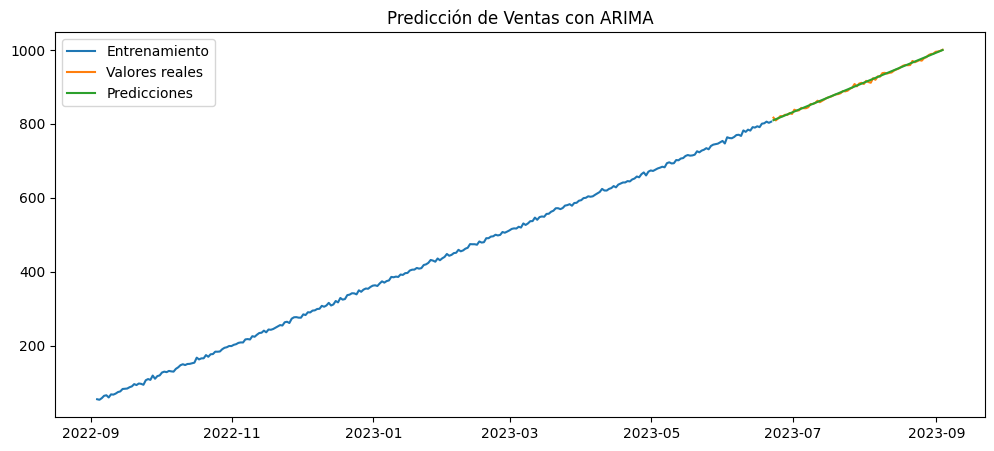

In [17]:
# Graficamos los valores reales vs las predicciones
plt.figure(figsize=(12, 5))
plt.plot(train, label='Entrenamiento')
plt.plot(test, label='Valores reales')
plt.plot(predicciones, label='Predicciones')
plt.title('Predicción de Ventas con ARIMA')
plt.legend()
plt.show()

In [18]:
# Medimos el rendimiento del modelo con dos métricas:
# MAE (Error Absoluto Medio): promedio de cuánto se equivoca el modelo en valor absoluto

mae = mean_absolute_error(test, predicciones)

print("MAE  (Error Absoluto Medio):", round(mae, 2))


MAE  (Error Absoluto Medio): 2.23


para saber si esun buen valor lo tengo que comprar con la media de la serie

In [19]:
# RMSE (Raíz del Error Cuadrático Medio): penaliza más los errores grandes

rmse = np.sqrt(mean_squared_error(test, predicciones))

print("RMSE (Raíz Error Cuadrático Medio):", round(rmse, 2))

RMSE (Raíz Error Cuadrático Medio): 2.8


In [20]:
#Comparo estos valores con la media de la serie para saber si el error es alto o bajo, como dije antes MAE

print("  Media de ventas en test:", round(test.mean(), 2))

  Media de ventas en test: 904.6


Entonces para entender estos valores sería para:

MAE: 2.23--> (2.23 / 904.6) * 100 = 0.25% de error

RMSE: 2.8 --> (2.8 / 904.6) * 100 = 0.31% de error

Ambos errores están por debajo del 1%, cuando lo aceptable es hasta el 10%. El modelo predice las ventas con una precisión altísima.